In [11]:
#gotowa funkcja do wizualizacji
def plot_decision_boundary_with_metrics(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    title="Model",
    show_precision=False
):
    """
    Plot decision boundary + metrics.

    Displays:
    - Train accuracy
    - Test accuracy
    - Optional precision
    """

    h = 0.02

    # Define grid
    x_min = min(X_train[:, 0].min(), X_test[:, 0].min()) - 1
    x_max = max(X_train[:, 0].max(), X_test[:, 0].max()) + 1
    y_min = min(X_train[:, 1].min(), X_test[:, 1].min()) - 1
    y_max = max(X_train[:, 1].max(), X_test[:, 1].max()) + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    # Predict grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Predictions on real data
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    if show_precision:
        precision = precision_score(y_test, y_test_pred)
        metrics_text = f"Train={train_acc:.2f} | Test={test_acc:.2f} | Prec={precision:.2f}"
    else:
        metrics_text = f"Train={train_acc:.2f} | Test={test_acc:.2f}"

    # Plot
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, marker='o', label="Train")
    plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, marker='x', label="Test")

    plt.title(f"{title}\n{metrics_text}")
    plt.legend()
    plt.show()


1. Generowanie danych
   Użyj biblioteki scikit-learn.
   Wygeneruj zbiór danych funkcją make_moons(n_samples=10000, noise=0.25).
   Podziel dane na zbiór uczący i testowy metodą train_test_split().

In [12]:
#importy
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, make_moons
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [13]:
# Generowanei danych
X, y = make_moons(n_samples=10000, noise=0.25)

#standaryzacja
scaler = StandardScaler()
X = scaler.fit_transform(X)

#podzial danych na zbior uczacy i treningowy
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
  )

2. Regresja logistyczna (własna implementacja)
   Zaimplementuj model w pliku reglog.py i wytrenuj klasyfikator.
   Napisz metodę zwracającą prawdopodobieństwa przynależności do klas.
   Nie używaj gotowych implementacji perceptronu ani regresji logistycznej z bibliotek.

In [14]:
# #wciagniecie modelu perceptronu z modelowego logreg_mmajew
import sys
sys.path.append("/content/drive/MyDrive/Colab Notebooks/MIW/Clusters")

import reglog_py
import importlib

importlib.reload(reglog_py)

from reglog_py import LogisticRegression

lreg =/= perceptron

rozni sie funkcja aktywacji (0/1 a sigmoid) i sposobem przedtawienia wyniku (klasa a prawdopodobienstwo)

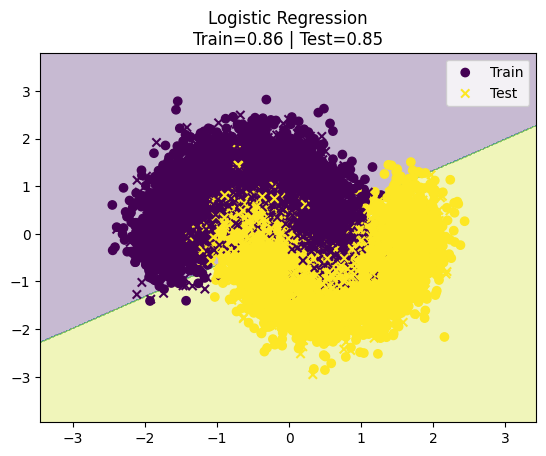

In [15]:
lreg = LogisticRegression()
lreg.fit(X_train, y_train)

plot_decision_boundary_with_metrics(
    lreg,
    X_train, y_train,
    X_test, y_test,
    "Logistic Regression"
)

3. Drzewo decyzyjne
   Użyj DecisionTreeClassifier.
   Porównaj kryteria: entropia oraz Gini.
   Sprawdź wpływ różnych głębokości drzewa.

Entropia:
- oparta na informacji przez co granice sa bardziej miękkie
- bardziej czuła
- bardziej zbalansowane wyniki

Gini:
- szybsza w obliczeniach
- bardziej "agresywne" podzialy
- przez mniejsze przywiazanie do informacji moze dawac lepsze wyniki

Depth - podzial na węzły:
- kazdy podzial dodaje "kontur" i umozliwia lepsze dopasowanie do ogolnego ksztaltu grupy
- czym wiecej podzialow tym zwieksza sie mozliwosc overfittingu

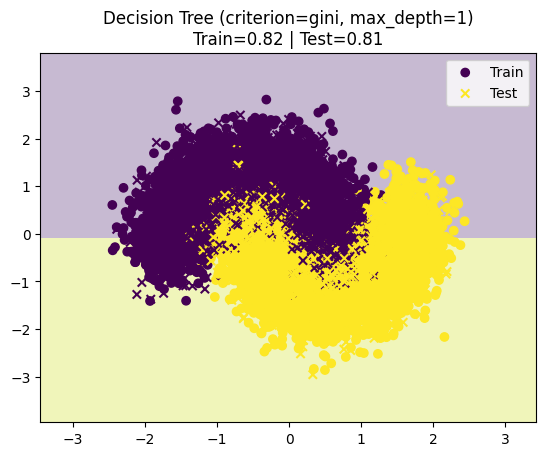

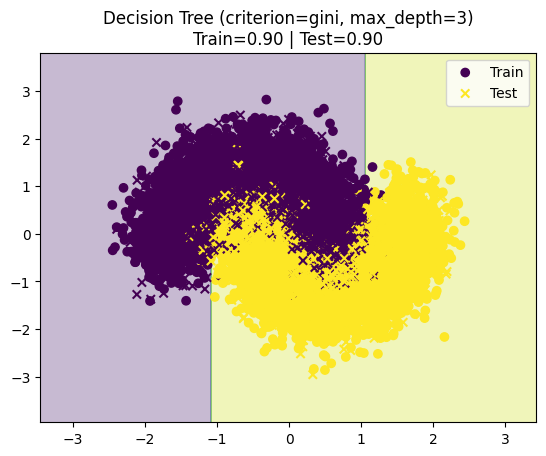

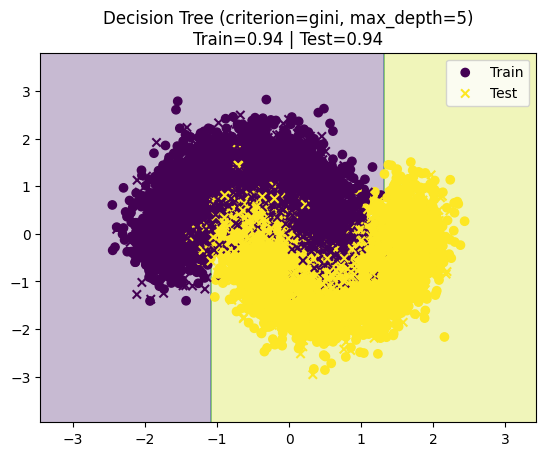

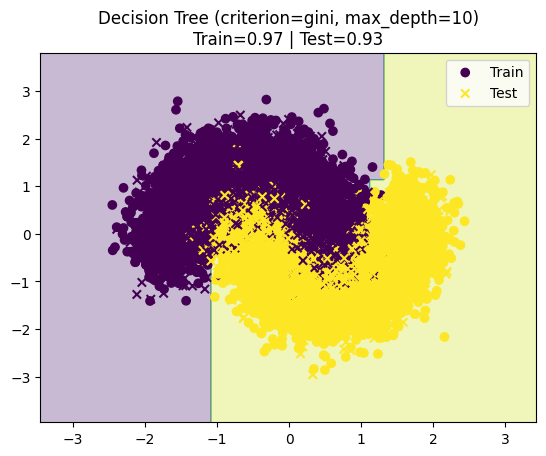

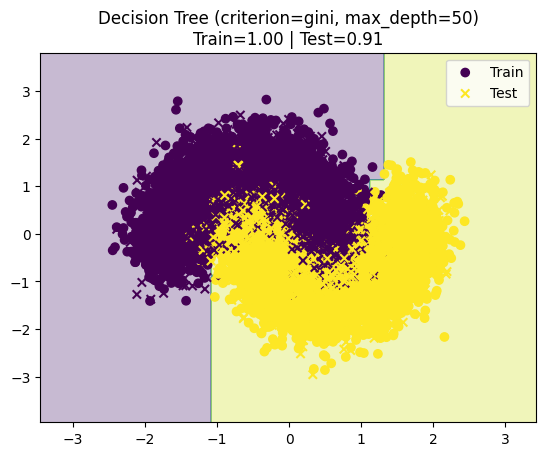

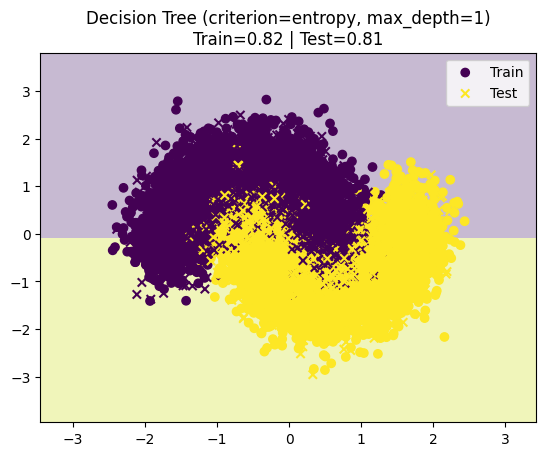

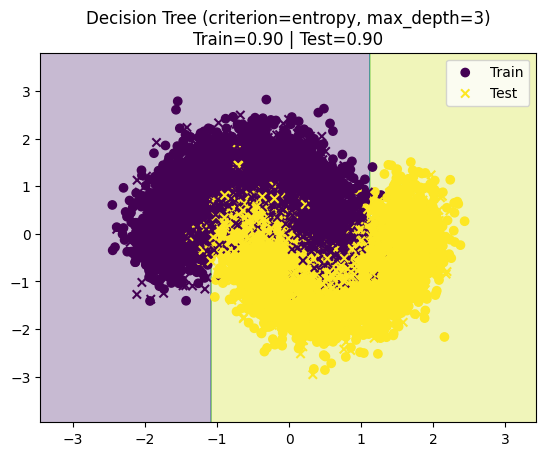

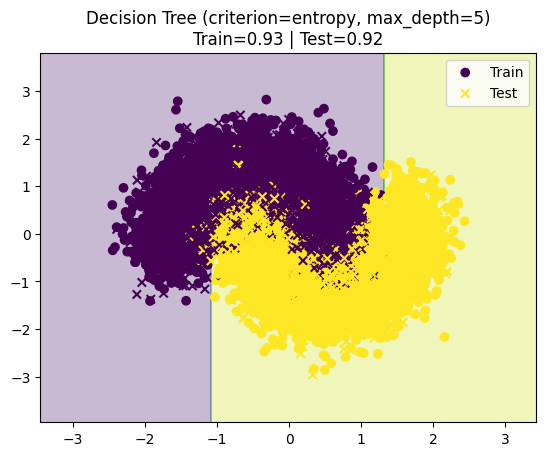

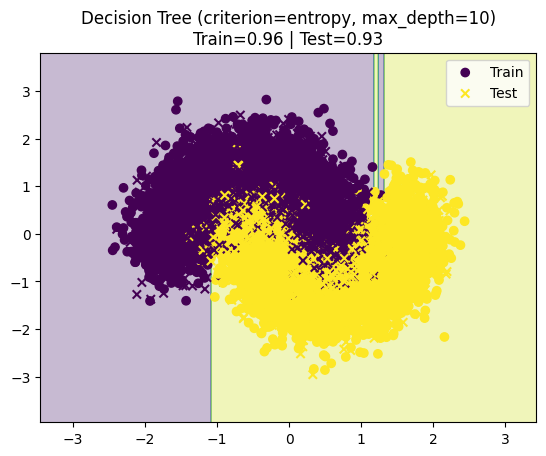

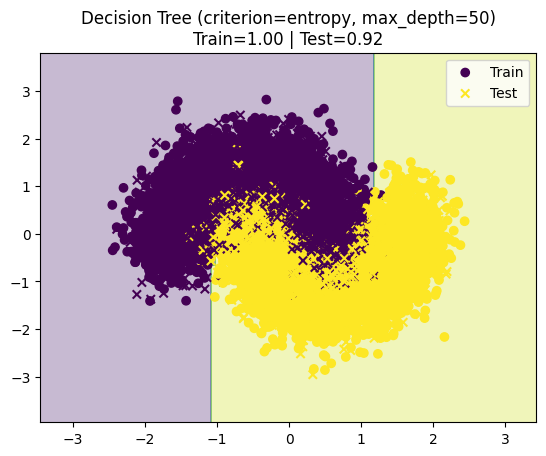

In [16]:
criteria = ['gini', 'entropy']
depths = [1,3,5,10,50]
treeForEvaluationGini = None
treeForEvaluationEntropy = None

for c in criteria:
  for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, criterion=c , random_state=42)
    tree.fit(X_train, y_train)

    if d == 5:
      if c == 'gini':
        treeForEvaluationGini = tree
      else:
        treeForEvaluationEntropy = tree

    plot_decision_boundary_with_metrics(
        tree,
        X_train, y_train,
        X_test, y_test,
        title = f"Decision Tree (criterion={c}, max_depth={d})"
    )

4. Las losowy
   Użyj RandomForestClassifier.
   Zbadaj wpływ liczby drzew na wyniki.

dla kazdego drzewa w lesie (kazde drzewo to n_estimator o depth = 3)
nauczenie na probce losowego podzbioru

potem dla kazdego punktu: glosowanie wszystkich drzew i decyzja wiekszoscia glosow


RandomForest > DecisionTree:
- kazde drzewo widzi inne dane przez podzial danych
- losowe cechy pozwalaja na zmniejszenie korelacji co redukuje overfitting
- glosowanie dodatkowo redukuje overfitting
- lepsze w generalizowaniu danych niz pojedyncze bo jest stabilniejsze gdy jest duzo drzew

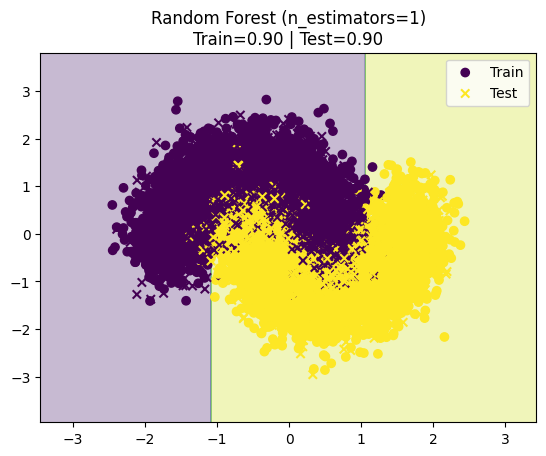

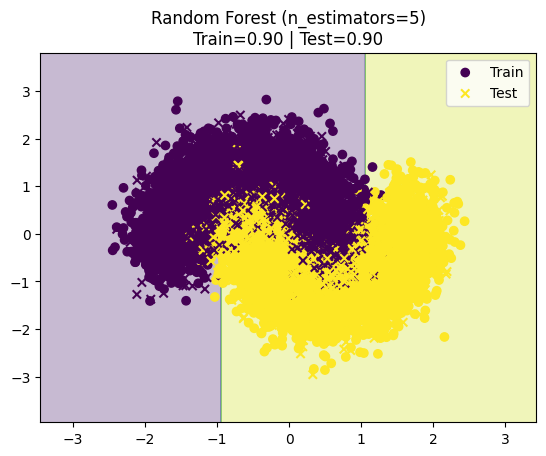

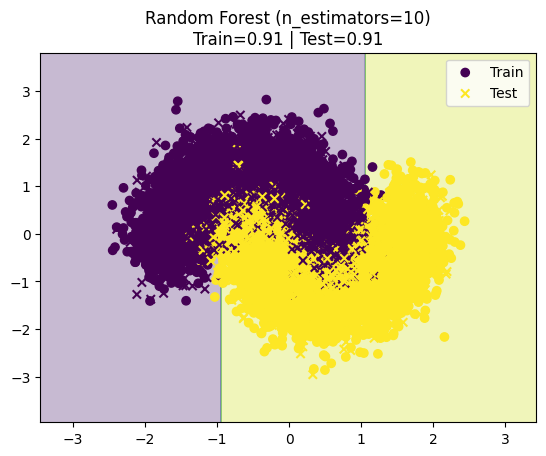

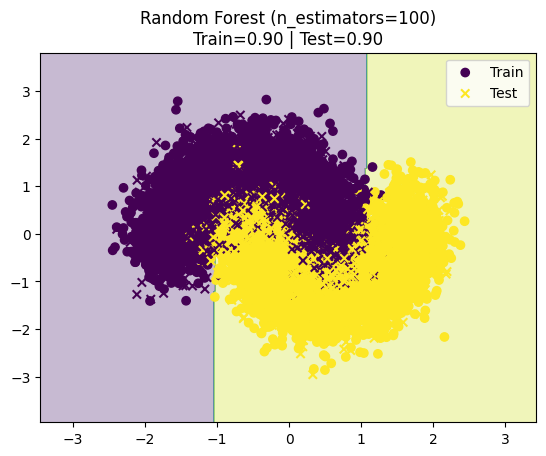

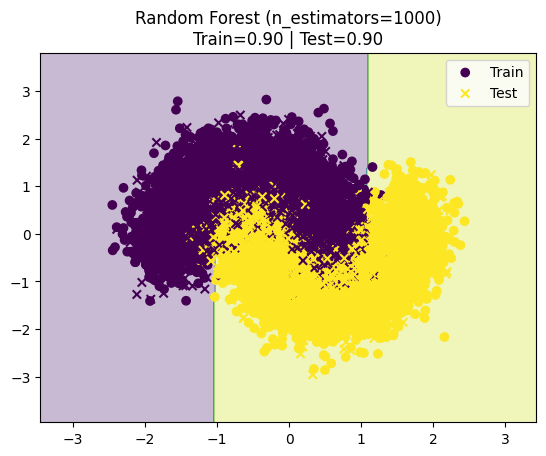

In [17]:
forest = [1,5,10,100,1000] #liczba drzew w lesie
forestForEvaluation = None

for t in forest:
  f = RandomForestClassifier(n_estimators=t, random_state=42, max_depth = 3)
  f.fit(X_train, y_train)
  if t == 10:
    forestForEvaluation = f

  plot_decision_boundary_with_metrics(
      f,
      X_train, y_train,
      X_test, y_test,
      title = f"Random Forest (n_estimators={t})"
  )

5. SVM
   Wytrenuj klasyfikator SVM.

geometrycze podejscie: oddzielenie klas z najszerszym marginesem pomiedzy punktami obydwu klas przez wyrysowanie prostej/krzywej lub plaszczyzny

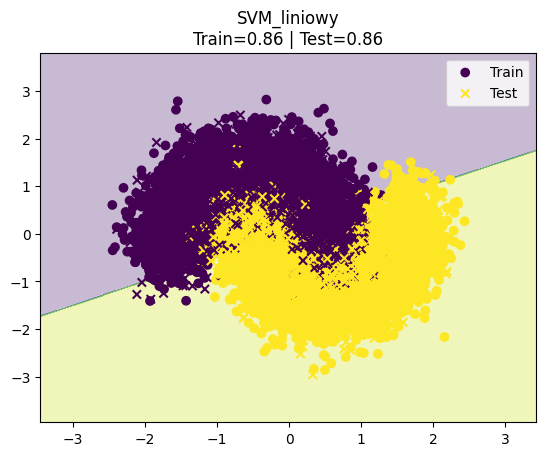

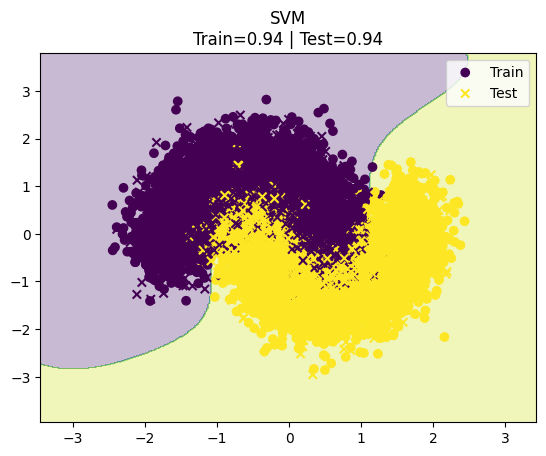

In [18]:
svm_liniowy = SVC(kernel = 'linear')#sposob wyrysowania liniowy
svm_liniowy.fit(X_train, y_train)

plot_decision_boundary_with_metrics(
    svm_liniowy,
    X_train, y_train,
    X_test, y_test,
    "SVM_liniowy"
)

svm = SVC(kernel = 'rbf')#sposob wyrysowania linii rbf = Radial Basis Function, zakrzywiona granica
svm.fit(X_train, y_train)

plot_decision_boundary_with_metrics(
    svm,
    X_train, y_train,
    X_test, y_test,
    "SVM"
)

6. Ensemble
   Połącz SVM, LogisticRegression oraz RandomForestClassifier w VotingClassifier.
  
VotingClassifier łączy modele (tu: SVC, logisticRegression i randomForestClassifier) aby poprawic dokladnosc i stabilnosc predykcji. Dodatkowo redukuje bledy pojedynczych modeli. Dziala najlepiej dla roznorodnych i niezaleznych od siebie modeli.

- Hard mode: kazdy model glosuje o klasie dla danego punktu i demokracja (najwiecej glosow wygrywa)
- Soft mode: kazdy model zwraca prawdopodobienstwo przynajleznosci do klasy i po wyciagnieciu sredniej nastepuje przyporzadkowanie

Accuracy: 0.9085


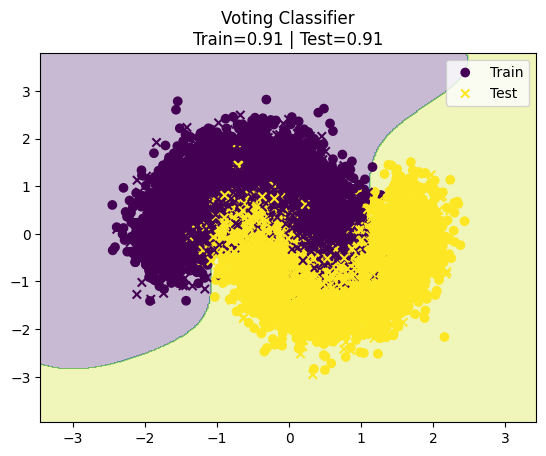

In [19]:
from sklearn.linear_model import LogisticRegression

voter = VotingClassifier(
    estimators = [
        # ("svm", svm), #dla voting "hard"
        ("svm", SVC(kernel = "rbf", probability = True)), #dla voting: "soft"
        ("perceptron_logisticRegression", LogisticRegression()),
        ("random_forest", forestForEvaluation)
    ],
    voting = "hard"
)

voter.fit(X_train, y_train)

y_pred = voter.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

plot_decision_boundary_with_metrics(
    voter,
    X_train, y_train,
    X_test, y_test,
    "Voting Classifier"
)

7. Ewaluacja
   Porównaj modele z punktów 2–6.
   Użyj metryk accuracy oraz wizualizacji granic decyzyjnych (decision boundaries).

sposob adaptacji przyporzadkowania dwuklasowego do wieloklasowego:

- OvR (One vs Rest) - stworzenie klasyfikatorow typu A vs ResztaKlas. Kazdy model mowi jak bardzo znajduje sie w danej klasie i najwyzszy wynik wygrywa
  - +: szybkie, liczba modeli odpowiada liczbie klas
  - -: granice moga sie nakladac, problem jesli klasy sa niezbalansowane
- OvO (One vs One) - stworzenie klasyfikatorow kazda klasa vs kazda. Kazdy model wybiera w ktorej z tych dwoch klas sie znajduje, najwiecej glosow wygrywa
  - +: lepsza jakosc porownan, prostsze problemy (2 klasy na raz)
  - -: kosztowne obliczeniowo bo duzo modeli (K(K-1)/2)

Logic Regression, accuracy: 0.853


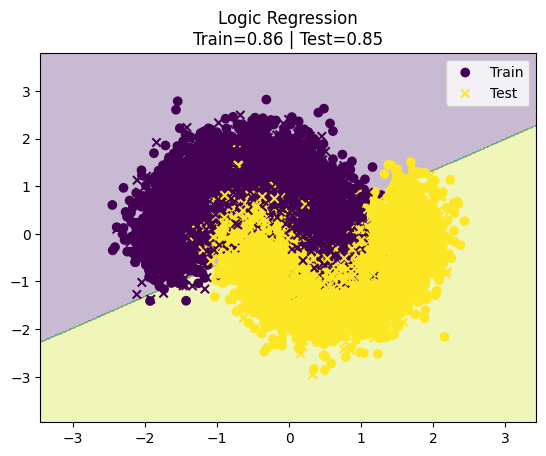

Decision Tree (criteria = 'gini', depth = 5), accuracy: 0.9395


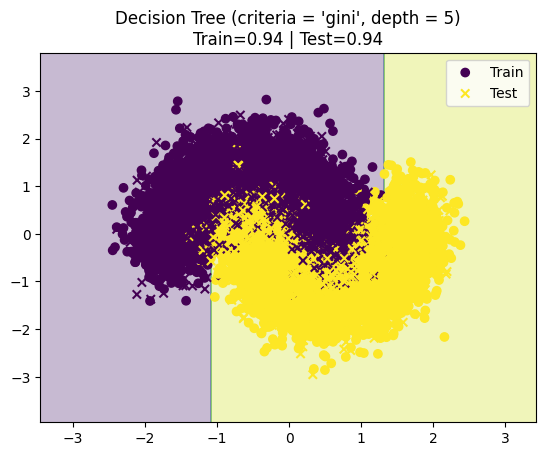

Decision Tree (criteria = 'entropy', depth = 5), accuracy: 0.9235


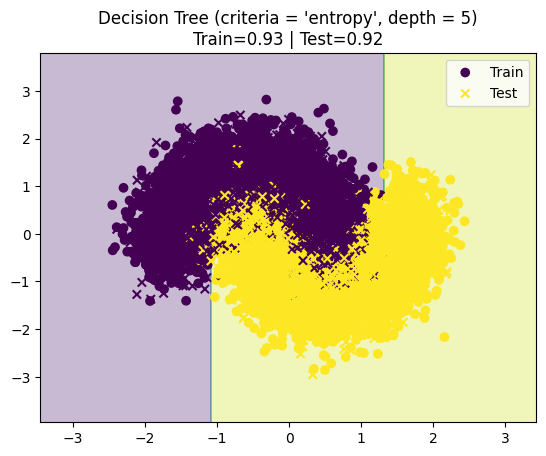

Random Forest (n_estimators = 10), accuracy: 0.907


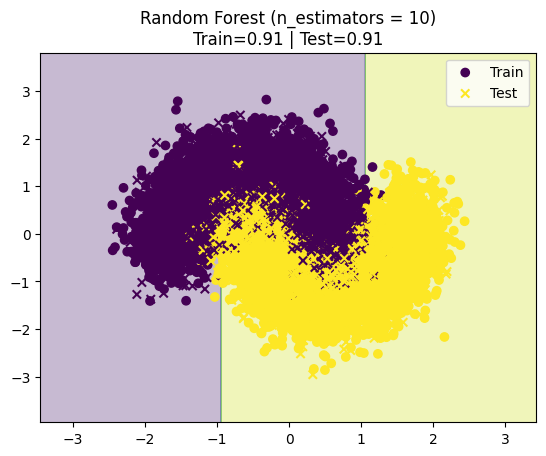

SVM, accuracy: 0.9415


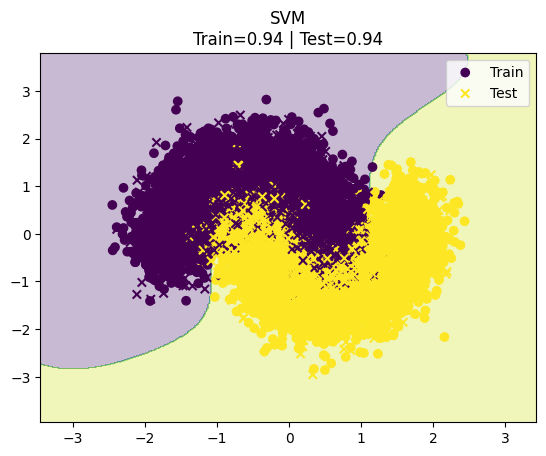

Voting Classifier, accuracy: 0.9085


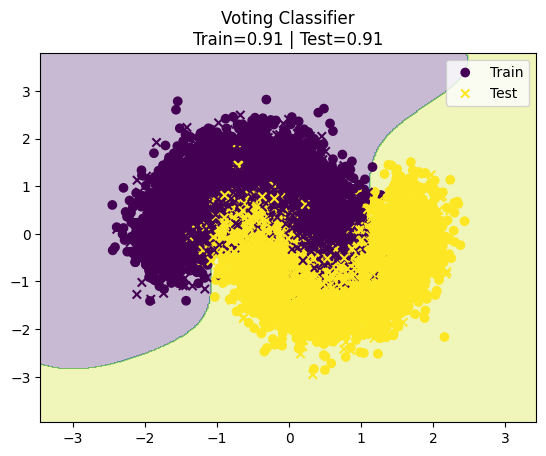

,model,accuracy
4,SVM,0.9415
1,"Decision Tree (criteria = 'gini', depth = 5)",0.9395
2,"Decision Tree (criteria = 'entropy', depth = 5)",0.9235
5,Voting Classifier,0.9085
3,Random Forest (n_estimators = 10),0.9070
0,Logic Regression,0.8530


In [21]:
import pandas as pd

models = [
    ("Logic Regression", lreg),
    (f"Decision Tree (criteria = 'gini', depth = {treeForEvaluationGini.get_depth()})", treeForEvaluationGini),
    (f"Decision Tree (criteria = 'entropy', depth = {treeForEvaluationEntropy.get_depth()})", treeForEvaluationEntropy),
    (f"Random Forest (n_estimators = {forestForEvaluation.n_estimators})", forestForEvaluation),
    ("SVM", svm),
    ("Voting Classifier", voter)
]
results = []

for model_name, model in models:
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test,y_pred)
    print(f"{model_name}, accuracy: {acc}")

    results.append({
        "model": model_name,
        "accuracy": acc
    })

    plot_decision_boundary_with_metrics(
        model,
        X_train, y_train,
        X_test, y_test,
        title = model_name
    )

results_df = pd.DataFrame(results)
results_df.sort_values(by="accuracy", ascending=False)